# Customer Segmentation Analysis
## Using K-Means Clustering on Mall Customers Data

**Goal:** Identify distinct customer groups based on income and spending behavior  
**Dataset:** Mall Customers dataset (200 customers, 5 variables)  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn  

---

In [1]:
# Cell 1 - Install libraries
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn", "scikit-learn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn'], returncode=0)

In [2]:
# Cell 2 - Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cell 3 - Load the data
df = pd.read_csv(r'C:\Users\Admin\Downloads\archive\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Rows and columns:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

Rows and columns: (200, 5)

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic stats:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [5]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore']
df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


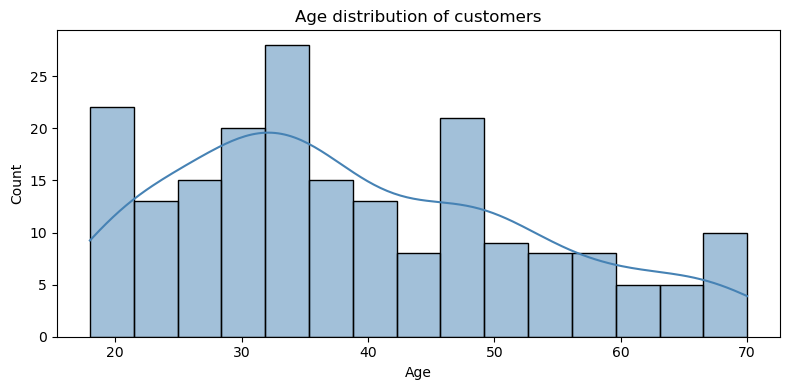

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=15, kde=True, color='steelblue')
plt.title('Age distribution of customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

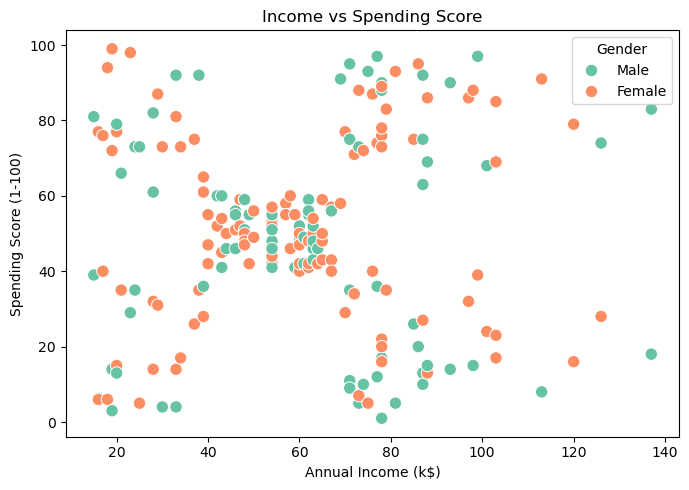

In [7]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Income', y='SpendingScore', hue='Gender', palette='Set2', s=80)
plt.title('Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()


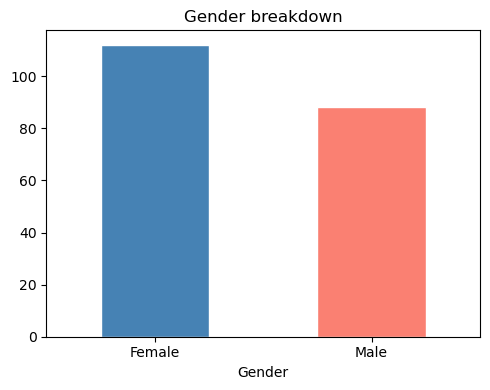

In [8]:
plt.figure(figsize=(5, 4))
df['Gender'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Gender breakdown')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

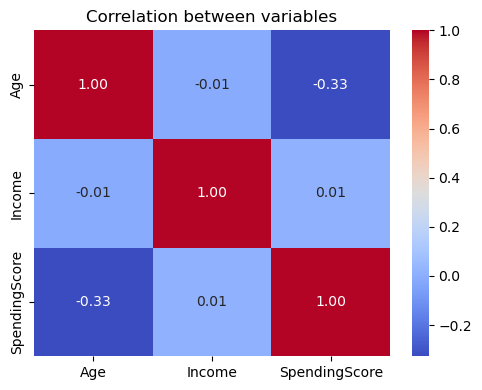

In [9]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[['Age', 'Income', 'SpendingScore']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between variables')
plt.tight_layout()
plt.show()

## Finding the Optimal Number of Clusters
Using the elbow method to determine the best value of k.
The curve bends sharply at k=5, meaning 5 clusters is the sweet spot.

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

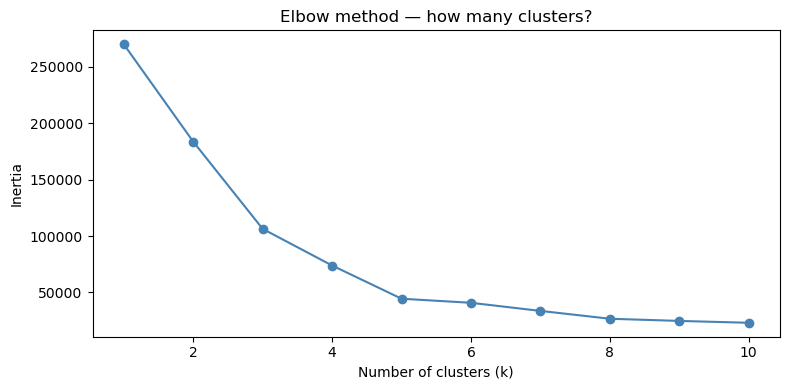

In [10]:
from sklearn.cluster import KMeans

# Try K-Means with 1 to 10 clusters and measure how tight each grouping is
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[['Income', 'SpendingScore']])
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='steelblue')
plt.title('Elbow method — how many clusters?')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [11]:
km = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = km.fit_predict(df[['Income', 'SpendingScore']])
df.head(10)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Income,SpendingScore,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


## Customer Segments
K-Means identified 5 distinct customer groups based on Annual Income and Spending Score.
Each color represents a different segment. The X marks show the cluster centers.

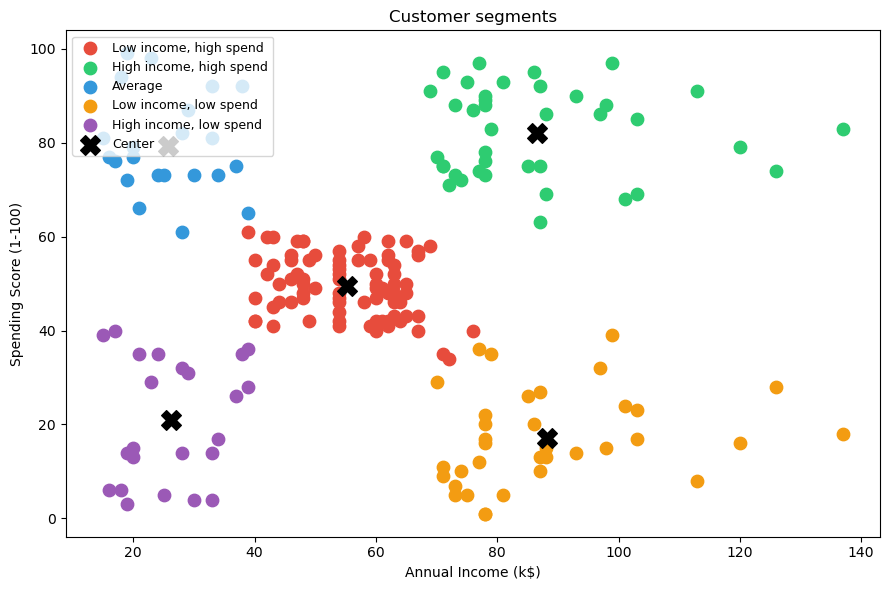

In [12]:
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
labels = ['Low income, high spend', 'High income, high spend', 
          'Average', 'Low income, low spend', 'High income, low spend']

plt.figure(figsize=(9, 6))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Income'], cluster_data['SpendingScore'],
                color=colors[i], label=labels[i], s=80)

# Plot cluster centers
centers = km.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Center')
/
plt.title('Customer segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Segment Profiles

| Segment | Income | Spending | Profile |
|---------|--------|----------|---------|
| Cluster 0 | Medium | Medium | Average customers |
| Cluster 1 | High | High | Prime targets — high value |
| Cluster 2 | Low | High | Impulsive young buyers |
| Cluster 3 | High | Low | Untapped potential |
| Cluster 4 | Low | Low | Budget conscious |

In [14]:
summary = df.groupby('Cluster')[['Age', 'Income', 'SpendingScore']].mean().round(1)
print(summary)

          Age  Income  SpendingScore
Cluster                             
0        42.7    55.3           49.5
1        32.7    86.5           82.1
2        25.3    25.7           79.4
3        41.1    88.2           17.1
4        45.2    26.3           20.9


## Business Recommendations

1. **Cluster 1 (High income, high spend)** — Priority segment. Focus premium marketing here.
2. **Cluster 2 (Low income, high spend)** — Offer loyalty rewards and discounts to retain them.
3. **Cluster 3 (High income, low spend)** — Investigate why they aren't spending. Better product range?
4. **Cluster 4 & 0** — Mass market campaigns, focus on value-for-money messaging.